# [Lec_OptDA-8주차] 파이썬 실습: 알고리즘 이해

* 활동-1. 숫자 맞추기 문제: Linear Search vs Binary Search
* 활동-2. 방정식 해 구하기: Bisection Method vs Newton-Raphson Method($x^2-2=0$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1. 숫자 맞추기 문제

In [7]:
def linear_search(target, low=1, high=100):
    guesses = []
    for n in range(low, high + 1):
        guesses.append(n)
        if n == target:
            return n, guesses
    return None, guesses

def binary_search(target, low=1, high=100):
    guesses = []
    left, right = low, high

    while left <= right:
        ###                  # mid = (left + right) // 2
        mid = (left + right) // 2
        guesses.append(mid)
        if mid == target:
            return mid, guesses
        elif mid < target:
            left = mid + 1
        else:
            right = mid - 1
    return None, guesses

In [8]:
TargetN = 73    ### 내가 선택한 숫자?
ans_linear, guesses_linear = linear_search(TargetN)
ans_binary, guesses_binary = binary_search(TargetN)

print("Target:", TargetN)
print("Linear Search guesses:", guesses_linear)
print("Linear Search number of guesses:", len(guesses_linear))
print("Binary Search guesses:", guesses_binary)
print("Binary Search number of guesses:", len(guesses_binary))

Target: 73
Linear Search guesses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73]
Linear Search number of guesses: 73
Binary Search guesses: [50, 75, 62, 68, 71, 73]
Binary Search number of guesses: 6


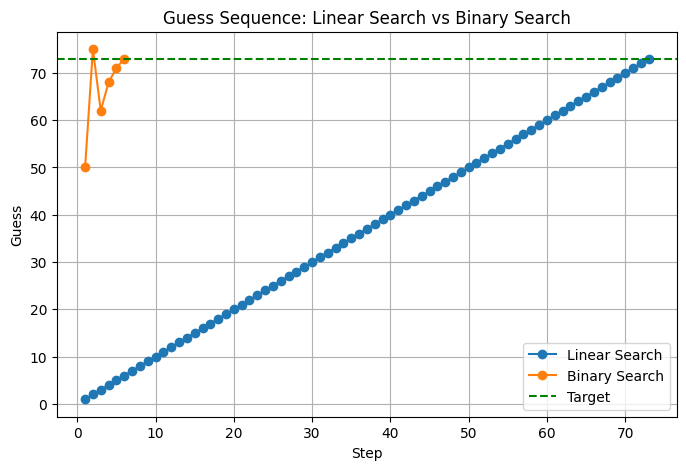

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(guesses_linear) + 1), guesses_linear, marker='o', label='Linear Search')
plt.plot(range(1, len(guesses_binary) + 1), guesses_binary, marker='o', label='Binary Search')
plt.axhline(TargetN, color='green',linestyle='--', label='Target')
plt.xlabel('Step')
plt.ylabel('Guess')
plt.title('Guess Sequence: Linear Search vs Binary Search')
plt.legend()
plt.grid(True)
plt.show()

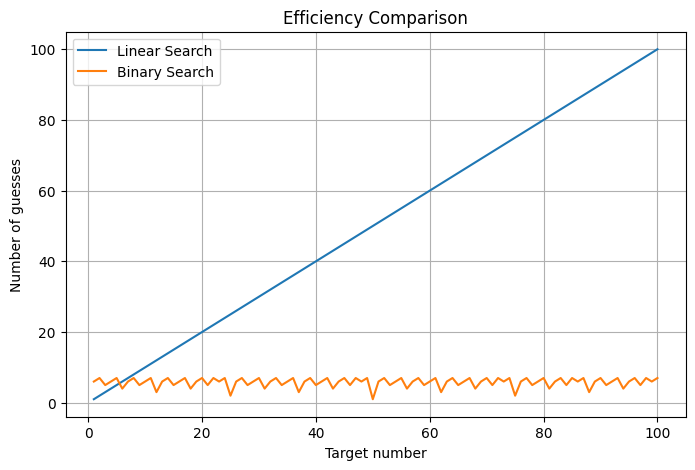

Average steps - Linear Search: 50.5
Average steps - Binary Search: 5.8

Worst-case steps - Linear Search: 100
Worst-case steps - Binary Search: 7
100
[  2   5   8  11  14  17  20  22  24  27  30  33  36  39  42  45  47  49
  52  55  58  61  64  67  70  72  74  77  80  83  85  87  90  93  96  98
 100]


In [16]:
linear_steps = []
binary_steps = []
targets = list(range(1, 101))
for T in targets:
    _, g1 = linear_search(T)
    _, g2 = binary_search(T)
    linear_steps.append(len(g1))
    binary_steps.append(len(g2))

plt.figure(figsize=(8, 5))
plt.plot(targets, linear_steps, label='Linear Search')
plt.plot(targets, binary_steps, label='Binary Search')
plt.xlabel('Target number')
plt.ylabel('Number of guesses')
plt.title('Efficiency Comparison')
plt.legend()
plt.grid(True)
plt.show()

print("Average steps - Linear Search:", np.mean(linear_steps))
print("Average steps - Binary Search:", np.mean(binary_steps))
print("")
print("Worst-case steps - Linear Search:", np.max(linear_steps))   ### max
print("Worst-case steps - Binary Search:", np.max(binary_steps))   ### max

np.where(linear_steps == np.max(linear_steps))
idx_linear_max = np.where(linear_steps == np.max(linear_steps))[0][0]
print(idx_linear_max+1)
np.where(binary_steps == np.max(binary_steps))
idx_binary_max = np.where(binary_steps == np.max(binary_steps))
print(idx_binary_max[0]+1)


## Part 2. $x^2 - 2 = 0$의 해 구하기

In [ ]:
def f(x):
    return x**2 - 2

def df(x):
    return 2*x

true_value = np.sqrt(2)
print("sqrt(2) =", true_value)

sqrt(2) = 1.4142135623730951


In [ ]:
def bisection_method(f, a, b, tol=1e-10, max_iter=100):
    if f(a) * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")
    history = []
    for k in range(max_iter):
        ####             # m = (a + b) / 2
        history.append(m)
        if abs(f(m)) < tol or (b - a) / 2 < tol:
            break
        if f(a) * f(m) <= 0:
            b = m
        else:
            a = m
    return history[-1], np.array(history)

def newton_method(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    history = [x]
    for k in range(max_iter):
        if abs(df(x)) < 1e-14:
            raise ValueError("Derivative is too close to zero.")
        ###x_new = x - ???                  # x_new = x - f(x) / df(x)
        history.append(x_new)
        if abs(f(x_new)) < tol or abs(x_new - x) < tol:
            break
        x = x_new
    return history[-1], np.array(history)

In [ ]:
root_bis, hist_bis = bisection_method(f, a=1, b=2, tol=1e-10, max_iter=100)
root_newton, hist_newton = newton_method(f, df, x0=1.5, tol=1e-10, max_iter=100)

print("Bisection root:", root_bis)
print("Bisection iterations:", len(hist_bis))
print("Bisection error:", abs(root_bis - true_value))
print("")
print("Newton root:", root_newton)
print("Newton iterations:", len(hist_newton)-1)
print("Newton error:", abs(root_newton - true_value))

Bisection root: 1.4142135623842478
Bisection iterations: 29
Bisection error: 1.1152634371569548e-11

Newton root: 1.4142135623746899
Newton iterations: 3
Newton error: 1.5947243525715749e-12


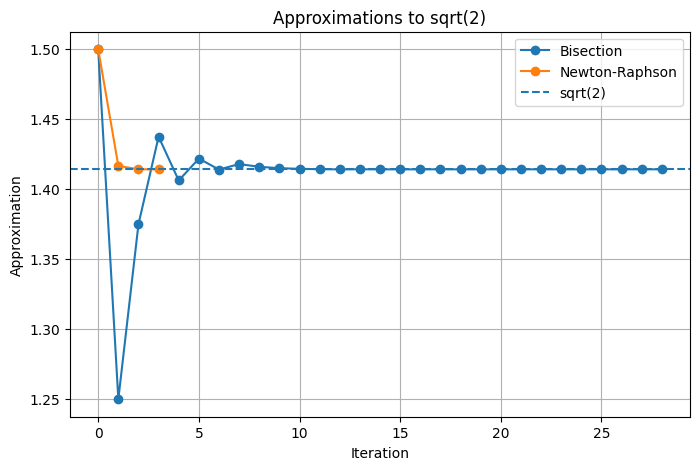

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_bis, marker='o', label='Bisection')
plt.plot(hist_newton, marker='o', label='Newton-Raphson')
plt.axhline(true_value, linestyle='--', label='sqrt(2)')
plt.xlabel('Iteration')
plt.ylabel('Approximation')
plt.title('Approximations to sqrt(2)')
plt.legend()
plt.grid(True)
plt.show()

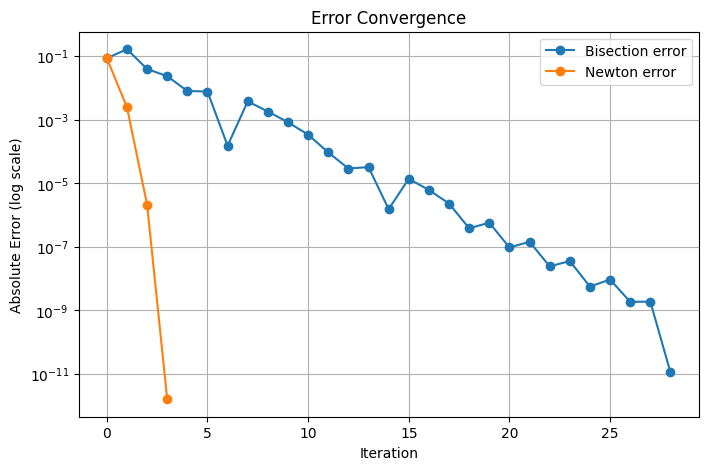

In [ ]:
err_bis = np.abs(hist_bis - true_value)
err_newton = np.abs(hist_newton - true_value)

plt.figure(figsize=(8, 5))
plt.semilogy(err_bis, marker='o', label='Bisection error')
plt.semilogy(err_newton, marker='o', label='Newton error')
plt.xlabel('Iteration')
plt.ylabel('Absolute Error (log scale)')
plt.title('Error Convergence')
plt.legend()
plt.grid(True)
plt.show()

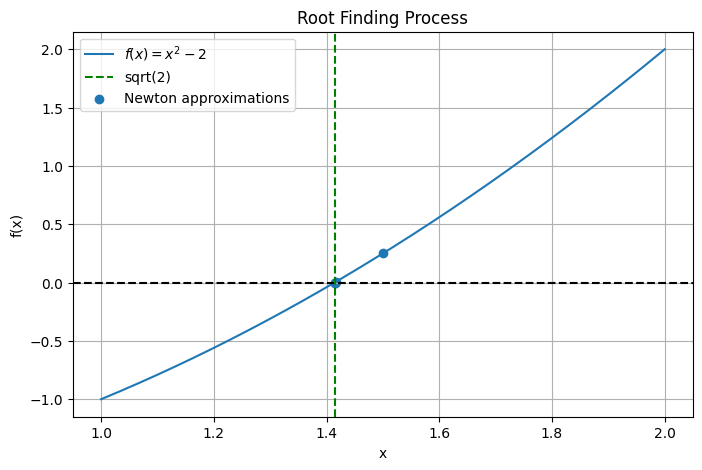

In [ ]:
x_grid = np.linspace(0.5, 2.2, 400)
y_grid = f(x_grid)
plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_grid, label='$f(x)=x^2-2$')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(true_value, color='g', linestyle='--', label='sqrt(2)')

#plt.scatter(hist_bis[:8], f(hist_bis[:8]), label='Bisection approximations')

plt.scatter(hist_newton, f(hist_newton), label='Newton approximations')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Root Finding Process')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
x0_values = [0.5, 1.0, 1.5, 3.0, 10.0]
for x0 in x0_values:
    root, hist = newton_method(f, df, x0=x0, tol=1e-10, max_iter=100)
    print(f"x0 = {x0:4.1f} | root = {root:.12f} | iterations = {len(hist)-1:2d} | error = {abs(root-true_value):.2e}")

x0 =  0.5 | root = 1.414213562373 | iterations =  6 | error = 0.00e+00
x0 =  1.0 | root = 1.414213562375 | iterations =  4 | error = 1.59e-12
x0 =  1.5 | root = 1.414213562375 | iterations =  3 | error = 1.59e-12
x0 =  3.0 | root = 1.414213562373 | iterations =  5 | error = 1.67e-14
x0 = 10.0 | root = 1.414213562373 | iterations =  7 | error = 2.22e-16
